In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
file_path=r"C:\ai ml\archive (5).zip"

In [3]:
df=pd.read_csv(file_path)

In [4]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
df.shape

(5110, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [7]:
df.duplicated().value_counts()

False    5110
Name: count, dtype: int64

In [8]:
print(df.isnull().sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


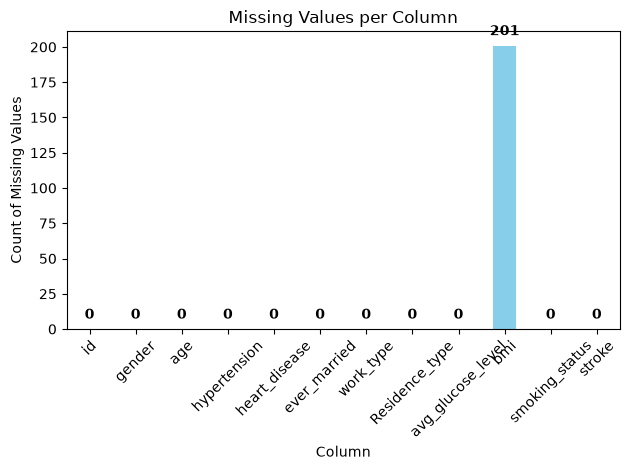

In [9]:
missing = df.isnull().sum()
ax = missing.plot(kind='bar', color='skyblue')
plt.title('Missing Values per Column')
plt.ylabel('Count of Missing Values')
plt.xlabel('Column')
plt.xticks(rotation=45)
for index, value in enumerate(missing):
    plt.text(index, value + 5, str(value), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [11]:
print(df.isnull().sum())

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


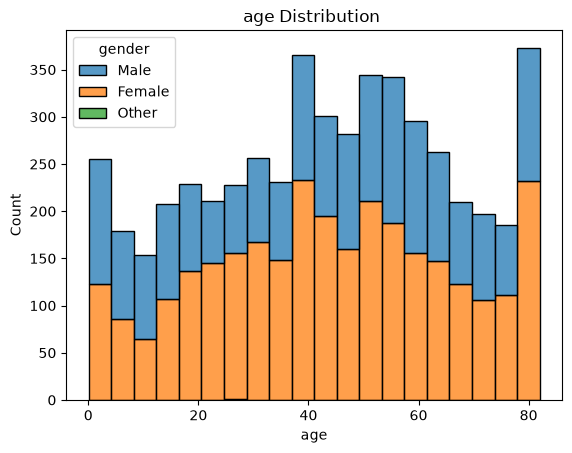

In [19]:
sns.histplot(data=df, x='age', hue='gender',multiple='stack',bins=20,color='skyblue')
plt.title('age Distribution ')
plt.xlabel('age')
plt.ylabel('Count')
plt.show()

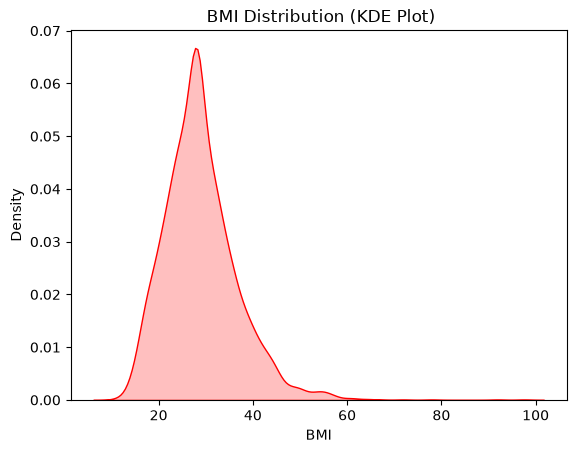

In [16]:
sns.kdeplot(df['bmi'], fill=True, color='red') 
plt.title(' BMI Distribution (KDE Plot)')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.show()

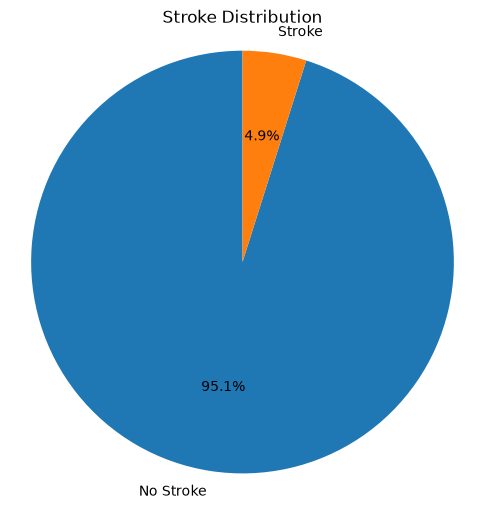

In [20]:
stroke_counts = df['stroke'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    stroke_counts,
    labels=['No Stroke', 'Stroke'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Stroke Distribution')
plt.axis('equal')
plt.show()

In [21]:
stroke_counts = df['stroke'].value_counts()

print("stroke Counts:\n", stroke_counts)

stroke Counts:
 stroke
0    4861
1     249
Name: count, dtype: int64


C:\Users\jiyarajan\AppData\Local\Temp\ipykernel_27352\144658335.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette='pastel')


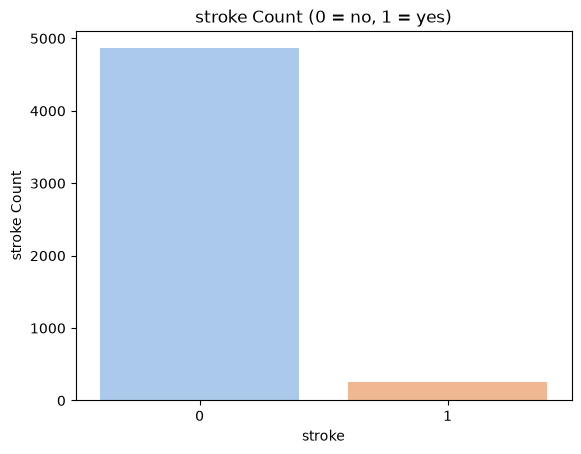

In [22]:
sns.countplot(x='stroke', data=df, palette='pastel')
plt.title('stroke Count (0 = no, 1 = yes)')
plt.xlabel('stroke')
plt.ylabel('stroke Count')
plt.show()

In [23]:
gender_counts = df['gender'].value_counts()
print("\ngender Counts:\n", gender_counts)


gender Counts:
 gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


In [24]:
stroke_by_gender = df.groupby(['gender', 'stroke']).size()
print("stroke by Gender:\n", stroke_by_gender)

stroke by Gender:
 gender  stroke
Female  0         2853
        1          141
Male    0         2007
        1          108
Other   0            1
dtype: int64


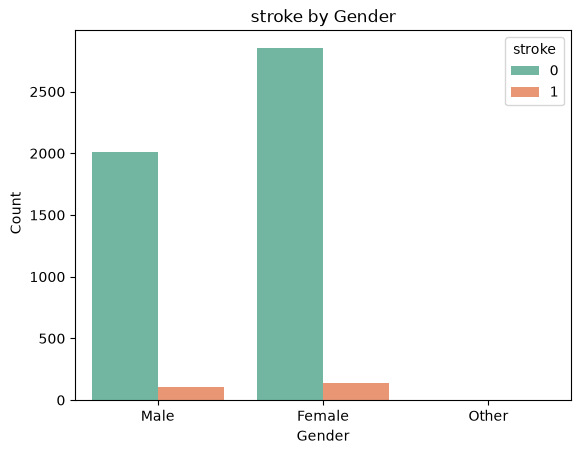

In [29]:
sns.countplot(x='gender', hue='stroke', data=df, palette='Set2')
plt.title('stroke by Gender')
plt.xlabel('Gender')
plt.ylabel(' Count')
plt.legend(title='stroke')
plt.show()